In [1]:
# ============================================================
# ELECTRICITY CONSUMPTION PREDICTION
# Week 4 - Supervised Learning: Regression
# ============================================================

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# ============================================================
# 2. CREATE DATASET
# ============================================================

np.random.seed(42)

n = 500

temperature = np.random.uniform(15, 40, n)
humidity = np.random.uniform(30, 90, n)
occupants = np.random.randint(1, 7, n)
appliances = np.random.randint(2, 15, n)
previous_consumption = np.random.uniform(5, 30, n)

# Create realistic electricity consumption
consumption = (
    2
    + 0.25 * temperature
    + 0.03 * humidity
    + 1.5 * occupants
    + 1.2 * appliances
    + 0.35 * previous_consumption
    + 0.015 * temperature**2
    + np.random.normal(0, 2, n)
)
df = pd.DataFrame({
    "Temperature": temperature,
    "Humidity": humidity,
    "Occupants": occupants,
    "Appliances": appliances,
    "Previous_Consumption": previous_consumption,
    "Electricity_Consumption": consumption
})

In [3]:
# ============================================================
# 3. EXPLORE DATASET
# ============================================================

print("First 5 rows:")
print(df.head())

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())


First 5 rows:
   Temperature   Humidity  Occupants  Appliances  Previous_Consumption  \
0    24.363503  71.889703          4           9             16.872164   
1    38.767858  62.165782          6          10             14.563157   
2    33.299849  48.571657          3          12              7.995725   
3    29.966462  78.827701          5           4             29.354116   
4    18.900466  71.083870          1          13              5.500659   

   Electricity_Consumption  
0                40.808535  
1                59.683822  
2                51.081360  
3                47.429389  
4                33.813247  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature              500 non-null    float64
 1   Humidity                 500 non-null    float64
 2   Occupants           

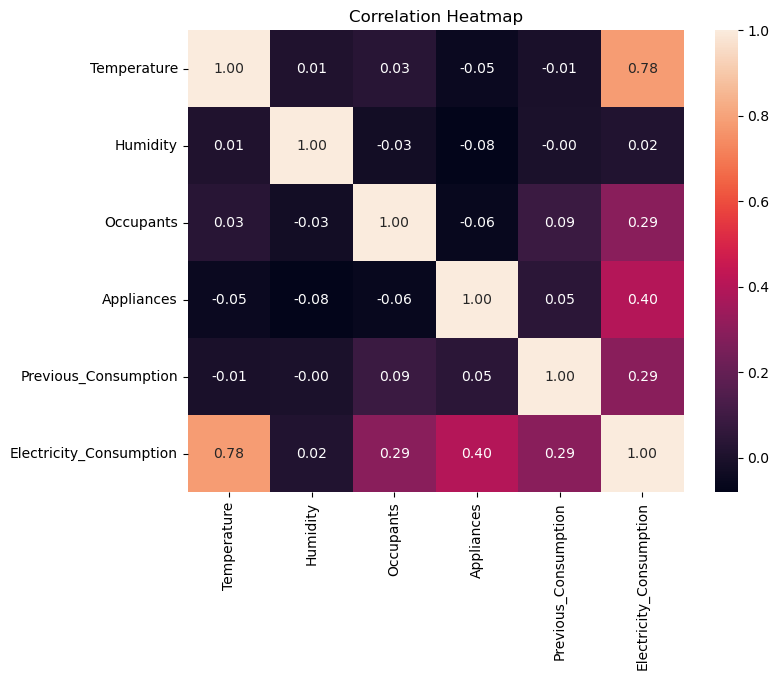

In [4]:
# ============================================================
# 4. EDA - CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(8, 6))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()


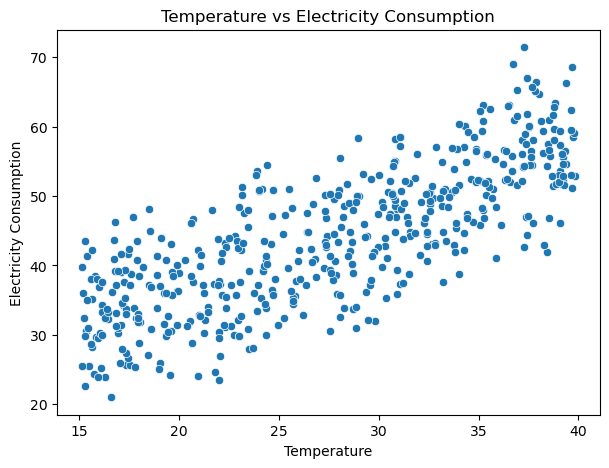

In [5]:
# ============================================================
# 5. VISUALIZE IMPORTANT RELATIONSHIPS
# ============================================================

plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="Temperature",
    y="Electricity_Consumption"
)

plt.title("Temperature vs Electricity Consumption")
plt.xlabel("Temperature")
plt.ylabel("Electricity Consumption")
plt.show()

In [6]:
# ============================================================
# 6. DEFINE FEATURES AND TARGET
# ============================================================

X = df[
    [
        "Temperature",
        "Humidity",
        "Occupants",
        "Appliances",
        "Previous_Consumption"
    ]
]

y = df["Electricity_Consumption"]


In [7]:
# ============================================================
# 7. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 400
Testing samples: 100


In [8]:
# ============================================================
# 8. FUNCTION TO EVALUATE MODELS
# ============================================================

def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)

    train_r2 = r2_score(y_train, train_predictions)
    test_r2 = r2_score(y_test, test_predictions)

    mae = mean_absolute_error(y_test, test_predictions)
    mse = mean_squared_error(y_test, test_predictions)
    rmse = np.sqrt(mse)

    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "Train R²": train_r2,
        "Test R²": test_r2
    }


In [9]:
# ============================================================
# 9. LINEAR REGRESSION
# ============================================================

linear_model = LinearRegression()

linear_result = evaluate_model(
    "Linear Regression",
    linear_model,
    X_train,
    X_test,
    y_train,
    y_test
)

In [10]:
# ============================================================
# 10. POLYNOMIAL REGRESSION
# ============================================================

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()

poly_model.fit(X_train_poly, y_train)

poly_train_pred = poly_model.predict(X_train_poly)
poly_test_pred = poly_model.predict(X_test_poly)

poly_mae = mean_absolute_error(y_test, poly_test_pred)
poly_mse = mean_squared_error(y_test, poly_test_pred)
poly_rmse = np.sqrt(poly_mse)

poly_train_r2 = r2_score(y_train, poly_train_pred)
poly_test_r2 = r2_score(y_test, poly_test_pred)

poly_result = {
    "Model": "Polynomial Regression",
    "MAE": poly_mae,
    "MSE": poly_mse,
    "RMSE": poly_rmse,
    "Train R²": poly_train_r2,
    "Test R²": poly_test_r2
}

In [11]:
# ============================================================
# 11. STANDARDIZE DATA FOR RIDGE AND LASSO
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [12]:
# ============================================================
# 12. RIDGE REGRESSION
# ============================================================

ridge_model = Ridge(alpha=1.0)

ridge_result = evaluate_model(
    "Ridge Regression",
    ridge_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

In [13]:
# ============================================================
# 13. LASSO REGRESSION
# ============================================================

lasso_model = Lasso(alpha=0.1)

lasso_result = evaluate_model(
    "Lasso Regression",
    lasso_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

In [14]:
# ============================================================
# 14. COMBINE ALL RESULTS
# ============================================================

results = pd.DataFrame([
    linear_result,
    poly_result,
    ridge_result,
    lasso_result
])

print("\n================ MODEL COMPARISON ================")

print(
    results.round(3)
)



================ MODEL COMPARISON ================
                   Model    MAE    MSE   RMSE  Train R²  Test R²
0      Linear Regression  1.852  5.274  2.297     0.956    0.947
1  Polynomial Regression  1.758  4.982  2.232     0.962    0.950
2       Ridge Regression  1.855  5.282  2.298     0.956    0.947
3       Lasso Regression  1.884  5.363  2.316     0.956    0.946


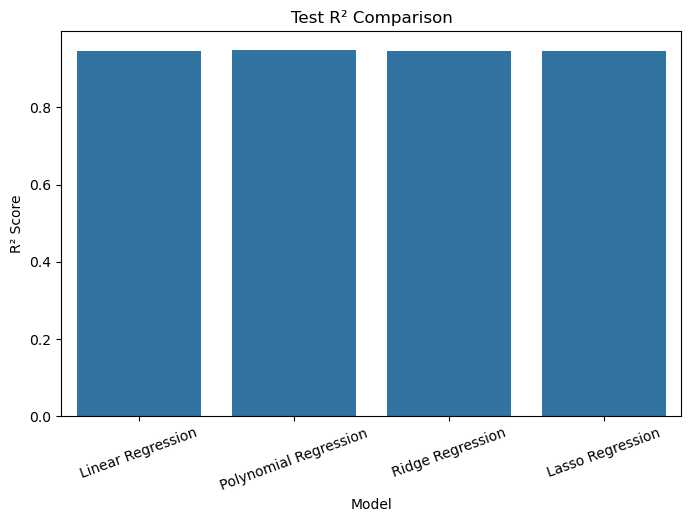

In [15]:
# ============================================================
# 15. R² COMPARISON
# ============================================================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=results,
    x="Model",
    y="Test R²"
)

plt.title("Test R² Comparison")
plt.xticks(rotation=20)
plt.ylabel("R² Score")
plt.show()

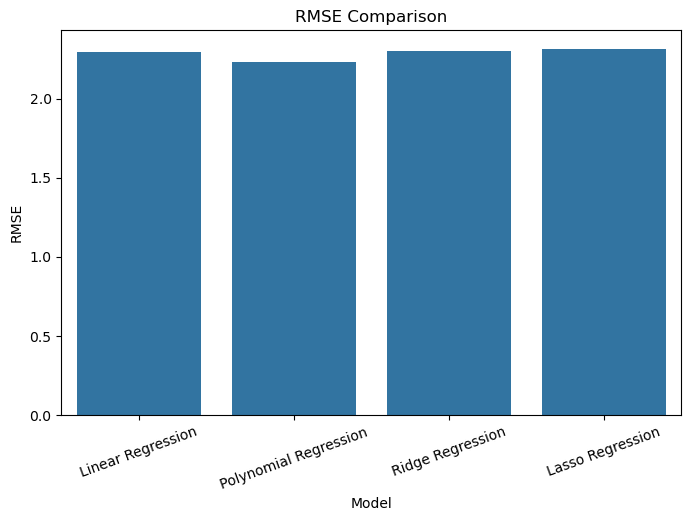

In [16]:
# ============================================================
# 16. RMSE COMPARISON
# ============================================================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=results,
    x="Model",
    y="RMSE"
)

plt.title("RMSE Comparison")
plt.xticks(rotation=20)
plt.ylabel("RMSE")
plt.show()

In [17]:
# ============================================================
# 17. TRAINING VS TESTING PERFORMANCE
# ============================================================

performance = results[
    ["Model", "Train R²", "Test R²"]
]

print("\n=============== TRAIN VS TEST R² ===============")

print(
    performance.round(3)
)


=============== TRAIN VS TEST R² ===============
                   Model  Train R²  Test R²
0      Linear Regression     0.956    0.947
1  Polynomial Regression     0.962    0.950
2       Ridge Regression     0.956    0.947
3       Lasso Regression     0.956    0.946


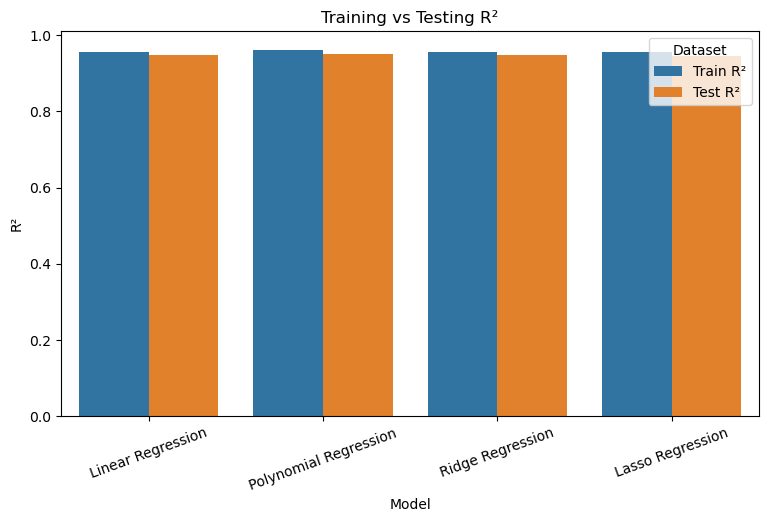

In [18]:
# ============================================================
# 18. VISUALIZE TRAIN VS TEST R²
# ============================================================

performance_melted = performance.melt(
    id_vars="Model",
    value_vars=["Train R²", "Test R²"],
    var_name="Dataset",
    value_name="R²"
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=performance_melted,
    x="Model",
    y="R²",
    hue="Dataset"
)

plt.title("Training vs Testing R²")
plt.xticks(rotation=20)
plt.show()


In [19]:
# ============================================================
# 19. POLYNOMIAL DEGREE ANALYSIS
# ============================================================

degrees = range(1, 6)

train_scores = []
test_scores = []

for degree in degrees:

    poly_temp = PolynomialFeatures(degree=degree)

    X_train_temp = poly_temp.fit_transform(X_train)
    X_test_temp = poly_temp.transform(X_test)

    model_temp = LinearRegression()

    model_temp.fit(
        X_train_temp,
        y_train
    )

    train_pred = model_temp.predict(X_train_temp)
    test_pred = model_temp.predict(X_test_temp)

    train_scores.append(
        r2_score(y_train, train_pred)
    )

    test_scores.append(
        r2_score(y_test, test_pred)
    )


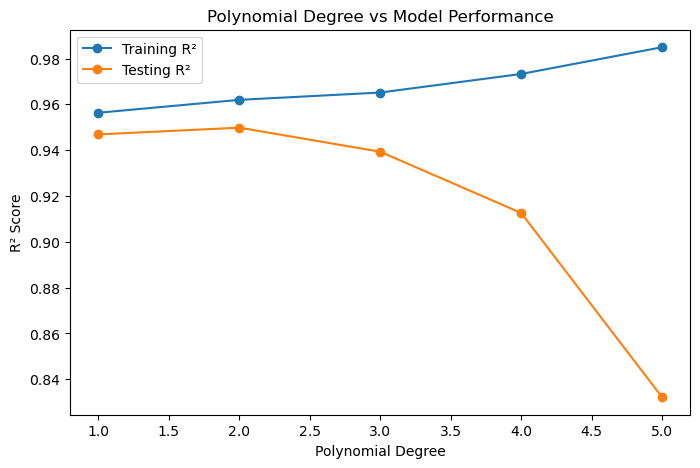

In [20]:
# ============================================================
# 20. PLOT BIAS-VARIANCE BEHAVIOR
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    degrees,
    train_scores,
    marker="o",
    label="Training R²"
)

plt.plot(
    degrees,
    test_scores,
    marker="o",
    label="Testing R²"
)

plt.xlabel("Polynomial Degree")
plt.ylabel("R² Score")

plt.title("Polynomial Degree vs Model Performance")

plt.legend()

plt.show()

In [21]:
# ============================================================
# 21. BEST MODEL
# ============================================================

best_model = results.loc[
    results["Test R²"].idxmax()
]

print("\n================ BEST MODEL ================")

print("Model:", best_model["Model"])
print("MAE:", round(best_model["MAE"], 3))
print("MSE:", round(best_model["MSE"], 3))
print("RMSE:", round(best_model["RMSE"], 3))
print("Test R²:", round(best_model["Test R²"], 3))



================ BEST MODEL ================
Model: Polynomial Regression
MAE: 1.758
MSE: 4.982
RMSE: 2.232
Test R²: 0.95
